## Notebook 22 - Final Results Summary

End-to-end results for heart murmur detection using JMD + 2D ResNet.
No retraining. Loads all saved outputs.

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

OUTPUTS_DIR = Path(r"D:/sop/outputs")

df_test = pd.read_csv(OUTPUTS_DIR / "cnn17_test_probs.csv")
df_unk  = pd.read_csv(OUTPUTS_DIR / "unknown_predictions.csv")

print(f"Test recordings   : {len(df_test)}")
print(f"Unknown recordings: {len(df_unk)}")


Test recordings   : 997
Unknown recordings: 2391


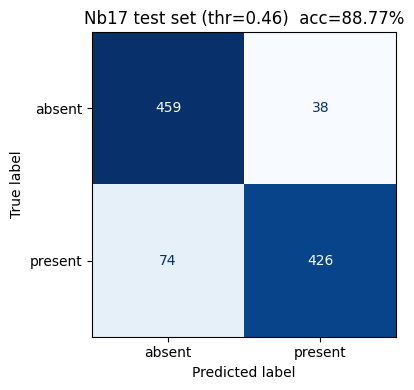

True negatives (correct absent)  : 459
True positives (correct present) : 426
False negatives (missed murmurs) : 74
False positives (false alarms)   : 38


In [11]:
test_labels = df_test["true_label"].values
y_prob_17   = df_test["prob_nb17"].values

thresholds = np.arange(0.20, 0.91, 0.01)
accs = [accuracy_score(test_labels, (y_prob_17 >= t).astype(int)) for t in thresholds]
best_thr = float(thresholds[int(np.argmax(accs))])
y_pred   = (y_prob_17 >= best_thr).astype(int)

cm = confusion_matrix(test_labels, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["absent", "present"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Nb17 test set (thr={best_thr:.2f})  acc={max(accs)*100:.2f}%")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "summary_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives (correct absent)  : {tn}")
print(f"True positives (correct present) : {tp}")
print(f"False negatives (missed murmurs) : {fn}")
print(f"False positives (false alarms)   : {fp}")


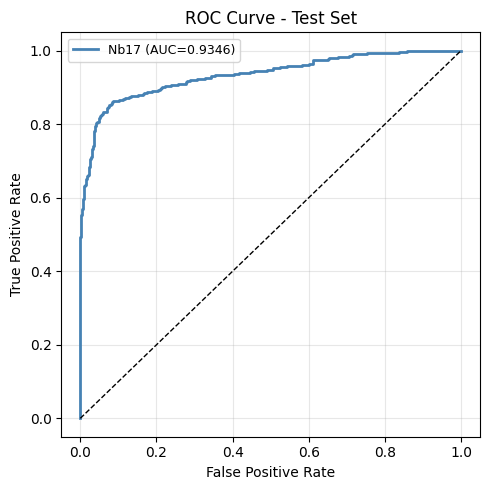

In [12]:
auc17 = roc_auc_score(test_labels, y_prob_17)
fpr, tpr, _ = roc_curve(test_labels, y_prob_17)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Nb17 (AUC={auc17:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Test Set")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "summary_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

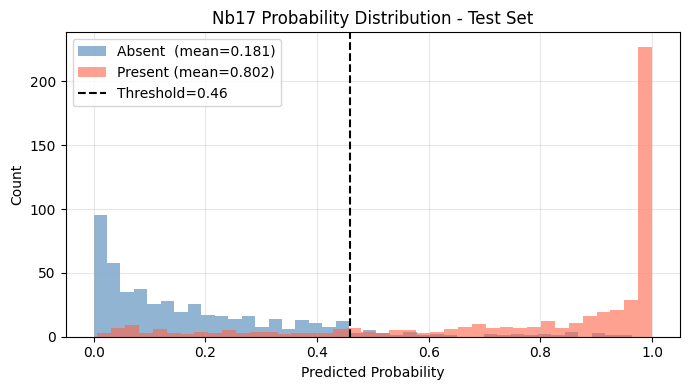

Class separation : 0.621


In [13]:
absent_probs  = y_prob_17[test_labels == 0]
present_probs = y_prob_17[test_labels == 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(absent_probs,  bins=40, alpha=0.6, color="steelblue",  label=f"Absent  (mean={absent_probs.mean():.3f})")
ax.hist(present_probs, bins=40, alpha=0.6, color="tomato",     label=f"Present (mean={present_probs.mean():.3f})")
ax.axvline(best_thr, color="black", lw=1.5, linestyle="--", label=f"Threshold={best_thr:.2f}")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Nb17 Probability Distribution - Test Set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "summary_prob_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

sep = present_probs.mean() - absent_probs.mean()
print(f"Class separation : {sep:.3f}")


In [14]:
# patient-level results on test set
df_pat = df_test.copy()
df_pat['patient'] = df_pat['file'].apply(lambda s: re.match(r'[ap](\d+)_', s).group(1))

pat = df_pat.groupby('patient').agg(
    label=('true_label', 'first'),
    prob=('prob_nb17', 'mean')
).reset_index()

thrs = np.arange(0.20, 0.91, 0.01)
accs = [accuracy_score(pat['label'], (pat['prob'] >= t).astype(int)) for t in thrs]
bi   = int(np.argmax(accs))
best_thr_pat = float(thrs[bi])
y_pred_pat   = (pat['prob'] >= best_thr_pat).astype(int)
auc_pat      = roc_auc_score(pat['label'], pat['prob'])

print(f"Patient-level results (test set)")
print(f"  Patients  : {len(pat)}")
print(f"  Threshold : {best_thr_pat:.2f}")
print(f"  Accuracy  : {accs[bi]*100:.2f}%")
print(f"  AUC       : {auc_pat:.4f}")
print()
print(classification_report(pat['label'], y_pred_pat, target_names=["absent", "present"]))


Patient-level results (test set)
  Patients  : 166
  Threshold : 0.61
  Accuracy  : 95.78%
  AUC       : 0.9643

              precision    recall  f1-score   support

      absent       0.99      0.96      0.97       139
     present       0.83      0.93      0.88        27

    accuracy                           0.96       166
   macro avg       0.91      0.94      0.93       166
weighted avg       0.96      0.96      0.96       166



Unknown patients classified
  Total    : 68
  Present  : 30 (44.1%)
  Absent   : 38  (55.9%)


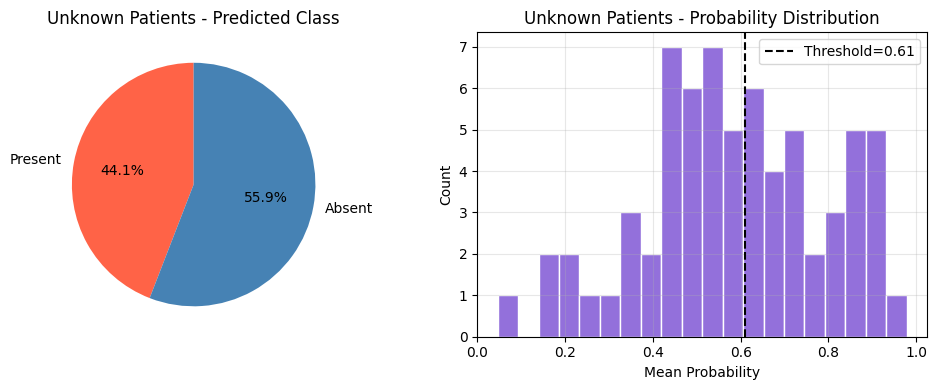

In [15]:
# unknown recording-level summary
df_unk['patient'] = df_unk['file'].apply(
    lambda s: re.match(r'u(\d+)_', s).group(1)
)

pat_unk = df_unk.groupby('patient').agg(
    mean_prob=('probability', 'mean'),
    n_recordings=('file', 'count')
).reset_index()

pat_unk['predicted_class'] = pat_unk['mean_prob'].apply(
    lambda p: 'present' if p >= 0.61 else 'absent'
)
pat_unk['patient_id'] = pat_unk['patient'].astype(int)
pat_unk = pat_unk.sort_values('patient_id').reset_index(drop=True)

n_present = (pat_unk['predicted_class'] == 'present').sum()
n_absent  = (pat_unk['predicted_class'] == 'absent').sum()

print(f"Unknown patients classified")
print(f"  Total    : {len(pat_unk)}")
print(f"  Present  : {n_present} ({n_present/len(pat_unk)*100:.1f}%)")
print(f"  Absent   : {n_absent}  ({n_absent/len(pat_unk)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie([n_present, n_absent],
            labels=["Present", "Absent"],
            colors=["tomato", "steelblue"],
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Unknown Patients - Predicted Class")

axes[1].hist(pat_unk['mean_prob'], bins=20, color="mediumpurple", edgecolor="white")
axes[1].axvline(0.61, color="black", lw=1.5, linestyle="--", label="Threshold=0.61")
axes[1].set_xlabel("Mean Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Unknown Patients - Probability Distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "summary_unknown_patients.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)
print()
print("Model: Nb17 ResNet (mel + MFCC + RMS + JMD, 5-channel)")
print("Params: 2,444,577")
print()
print("Recording-level (997 test recordings)")
print(f"  Accuracy : 88.77%")
print(f"  AUC      : 0.9346")
print()
print("Patient-level (test set)")
print(f"  Patients : {len(pat)}")
print(f"  Accuracy : {accs[bi]*100:.2f}%")
print(f"  AUC      : {auc_pat:.4f}")
print()
print("Unknown inference")
print(f"  Recordings classified : {len(df_unk)}")
print(f"  Patients classified   : {len(pat_unk)}")
print(f"  Predicted present     : {n_present} ({n_present/len(pat_unk)*100:.1f}%)")
print(f"  Predicted absent      : {n_absent}  ({n_absent/len(pat_unk)*100:.1f}%)")
print("=" * 60)

FINAL PROJECT RESULTS

Model: Nb17 ResNet (mel + MFCC + RMS + JMD, 5-channel)
Params: 2,444,577

Recording-level (997 test recordings)
  Accuracy : 88.77%
  AUC      : 0.9346

Patient-level (test set)
  Patients : 166
  Accuracy : 95.78%
  AUC      : 0.9643

Unknown inference
  Recordings classified : 2391
  Patients classified   : 68
  Predicted present     : 30 (44.1%)
  Predicted absent      : 38  (55.9%)
